In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import string
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras import layers
from nltk.tokenize import word_tokenize
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
!pip install sentence-transformers rapidfuzz nltk


In [ ]:
!pip install -q sentence-transformers rapidfuzz scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import re
import json

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

df = pd.read_csv('/content/drive/MyDrive/Classroom/English/english_train.csv')

cols = list(df.columns)

article_col = next(
    (c for c in cols
     if 'article' in c.lower()
     or 'text' in c.lower()
     or 'body' in c.lower()),
    None
)

summary_col = next(
    (c for c in cols
     if 'summary' in c.lower()
     or 'abstract' in c.lower()),
    None
)

if article_col is None:
    raise ValueError("Article column not found")

if summary_col is None:
    raise ValueError("Summary column not found")

print("Article Column:", article_col)
print("Summary Column:", summary_col)

N = 10
df = df.iloc[:N]


def split_sentences(text):

    if pd.isna(text):
        return []

    text = str(text).strip()

    sentences = re.split(
        r'(?<=[.!?])\s+',
        text
    )

    return [
        s.strip()
        for s in sentences
        if len(s.strip()) > 3
    ]

model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

rows = []
global_id = 0

for article_number, row in df.iterrows():

    article_text = str(row[article_col])
    summary_text = str(row[summary_col])

    article_sentences = split_sentences(article_text)

    if len(article_sentences) == 0:
        continue

    sentence_embeddings = model.encode(
        article_sentences,
        convert_to_numpy=True
    )

    summary_embedding = model.encode(
        summary_text,
        convert_to_numpy=True
    )

    similarities = cosine_similarity(
        sentence_embeddings,
        summary_embedding.reshape(1, -1)
    ).flatten()

    top_k = max(
        1,
        int(len(article_sentences) * 0.30)
    )

    important_idx = set(
        similarities.argsort()[-top_k:]
    )

    for sent_idx, sentence in enumerate(article_sentences):

        label = 1 if sent_idx in important_idx else 0

        rows.append({

            "id": global_id,

            "Article_number": article_number,

            "Sentence_number": f"S{sent_idx+1}",

            "Sentence": sentence,

            "Label": label,

            "sentence_embedding":
                json.dumps(
                    sentence_embeddings[sent_idx].tolist()
                )
        })

        global_id += 1

sentence_df = pd.DataFrame(rows)

print(sentence_df.head())

print("\nShape:", sentence_df.shape)

output_file = "sentence_level_dataset.csv"

sentence_df.to_csv(
    output_file,
    index=False
)

print(f"\nSaved: {output_file}")

Article Column: Article
Summary Column: Summary


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

   id  Article_number Sentence_number  \
0   0               0              S1   
1   1               0              S2   
2   2               0              S3   
3   3               0              S4   
4   4               0              S5   

                                            Sentence  Label  \
0  Barbie Movie Review: One mention of Barbie and...      1   
1  This stereotype is stuck with the doll for yea...      0   
2  Director Greta Gerwig understood these stereot...      1   
3  However, she shatters the glass as soon as she...      1   
4  We see the stereotype Barbie (Margot), the Pre...      0   

                                  sentence_embedding  
0  [0.01527478825300932, 0.000609935203101486, -0...  
1  [0.0203480813652277, -0.044019754976034164, 0....  
2  [0.05134015157818794, -0.04031342640519142, 0....  
3  [0.06547439843416214, -0.06809450685977936, -0...  
4  [0.05251152813434601, -0.04865412414073944, -0...  

Shape: (115, 6)

Saved: sentence_level_data

In [ ]:
data = pd.read_csv('/content/sentence_level_dataset.csv')
data = data.head(324)
idx=data['Article_number']
article_number = data['Article_number']
sentence_number = data['Sentence_number']
sentence = data['Sentence']
label = data['Label']
sentence_embedding = data['sentence_embedding']


In [ ]:
article_number

9

In [ ]:
data

,id,Article_number,Sentence_number,Sentence,Label,sentence_embedding
0,0,0,S1,Barbie Movie Review: One mention of Barbie and...,1,"[0.01527478825300932, 0.000609935203101486, -0..."
1,1,0,S2,This stereotype is stuck with the doll for yea...,0,"[0.0203480813652277, -0.044019754976034164, 0...."
2,2,0,S3,Director Greta Gerwig understood these stereot...,1,"[0.05134015157818794, -0.04031342640519142, 0...."
3,3,0,S4,"However, she shatters the glass as soon as she...",1,"[0.06547439843416214, -0.06809450685977936, -0..."
4,4,0,S5,"We see the stereotype Barbie (Margot), the Pre...",0,"[0.05251152813434601, -0.04865412414073944, -0..."
...,...,...,...,...,...,...
110,110,8,S13,The tiger estimation survey began in 2006 and ...,0,"[-0.033971045166254044, -0.05984318628907204, ..."
111,111,8,S14,"In fact, according to the central government, ...",0,"[0.12083970755338669, -0.06041102856397629, 0...."
112,112,9,S1,The local administration on Saturday demolishe...,0,"[0.012461007572710514, 0.10714782029390335, -0..."
113,113,9,S2,But they went ahead with the demolition.The du...,1,"[-0.05774388089776039, 0.12071329355239868, -0..."


In [ ]:
import re

def remove_special_characters(text):
    # Remove @ symbols
    text = re.sub(r'@', '', text)
    # Remove hashtags
    text = re.sub(r'#\w+', '', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text=re.sub(r'\xa0','',text)
    return text



In [ ]:
data['Sentence'] = data['Sentence'].apply(remove_special_characters)
data['Sentence']

,Sentence
0,Barbie Movie Review: One mention of Barbie and...
1,This stereotype is stuck with the doll for yea...
2,Director Greta Gerwig understood these stereot...
3,"However, she shatters the glass as soon as she..."
4,"We see the stereotype Barbie (Margot), the Pre..."
...,...
110,The tiger estimation survey began in 2006 and ...
111,"In fact, according to the central government, ..."
112,The local administration on Saturday demolishe...
113,But they went ahead with the demolition.The du...


In [ ]:
from posixpath import join
cleand_tweet = []
for i in range(len(data)):
        text = data['Sentence'][i]



        translator = str.maketrans('', '', string.punctuation)
        cleaned_text = text.translate(translator)
        cleand_tweet.append(cleaned_text)

print(cleand_tweet)


['Barbie Movie Review One mention of Barbie and you instantly think of a lean tallfigured doll who is always welldressed and has a perfect life', 'This stereotype is stuck with the doll for years despite the numerous new designs and models being introduced', 'Director Greta Gerwig understood these stereotypes and even plays along with them for the first 15 to 20 minutes of the Barbie movie', 'However she shatters the glass as soon as she is done playing with the ampdollamp and gets down to business to tell a relatable feminist and applaudworthy movie that lives up to the hypeBarbie starring Margot Robbie in the lead is set in Barbie Land which has several kinds of Barbies coexisting', 'We see the stereotype Barbie Margot the President Barbie Issa Rae Physicist Barbie Emma Mackey and Lawyer Barbie Sharon Rooney among many more running the Barbie land while the men all of them named Ken double up as their supporters lovers and partnersAll goes well in the alter imaginary world until one 

In [ ]:
tfidf_vectorizer = TfidfVectorizer()
nodes = tfidf_vectorizer.fit_transform(cleand_tweet)
print(nodes.shape)
nodes = nodes.toarray()
cosine_similarities = cosine_similarity(nodes, nodes)
cosine_similarities

(115, 1835)


array([[1.        , 0.08616319, 0.11814746, ..., 0.04644314, 0.04707875,
        0.0515292 ],
       [0.08616319, 1.        , 0.06745932, ..., 0.07348074, 0.06258992,
        0.07341501],
       [0.11814746, 0.06745932, 1.        , ..., 0.06717051, 0.06430792,
        0.07679724],
       ...,
       [0.04644314, 0.07348074, 0.06717051, ..., 1.        , 0.2966769 ,
        0.29972776],
       [0.04707875, 0.06258992, 0.06430792, ..., 0.2966769 , 1.        ,
        0.23408243],
       [0.0515292 , 0.07341501, 0.07679724, ..., 0.29972776, 0.23408243,
        1.        ]])

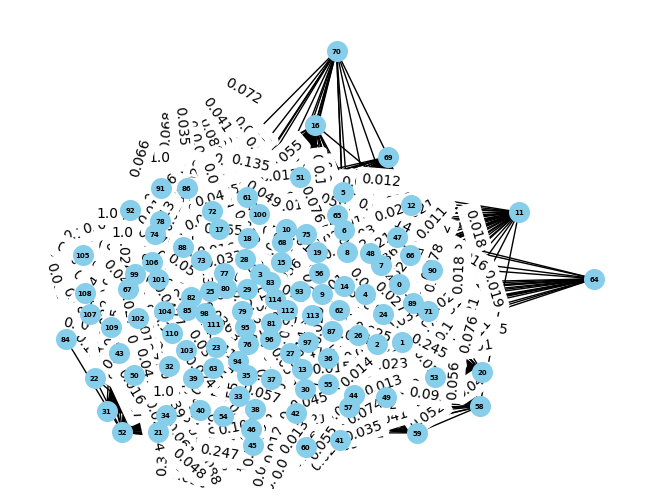

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

G = nx.Graph()

for i in range(len(cosine_similarities)):

    for j in range( len(cosine_similarities[0])):
        if cosine_similarities[i][j] > 0.01 and cosine_similarities[i][j] < 1:
            G.add_edge(i, j, weight=round(cosine_similarities[i][j],3))
pos = nx.spring_layout(G)

nx.draw(G, with_labels=True, node_size=200, node_color='skyblue', font_size=5, font_weight='bold')
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G,pos, edge_labels=labels)
plt.savefig('Graph.png')
#plt.show()


In [ ]:
from networkx.readwrite import json_graph

In [ ]:
json_data = json_graph.node_link_data(G)
json_data

{'directed': False,
 'multigraph': False,
 'graph': {},
 'nodes': [{'id': 0},
  {'id': 1},
  {'id': 2},
  {'id': 3},
  {'id': 4},
  {'id': 5},
  {'id': 6},
  {'id': 7},
  {'id': 8},
  {'id': 9},
  {'id': 10},
  {'id': 12},
  {'id': 13},
  {'id': 14},
  {'id': 15},
  {'id': 16},
  {'id': 17},
  {'id': 18},
  {'id': 19},
  {'id': 23},
  {'id': 25},
  {'id': 26},
  {'id': 27},
  {'id': 28},
  {'id': 29},
  {'id': 30},
  {'id': 31},
  {'id': 32},
  {'id': 35},
  {'id': 36},
  {'id': 37},
  {'id': 38},
  {'id': 40},
  {'id': 41},
  {'id': 42},
  {'id': 44},
  {'id': 45},
  {'id': 46},
  {'id': 48},
  {'id': 49},
  {'id': 52},
  {'id': 54},
  {'id': 55},
  {'id': 56},
  {'id': 57},
  {'id': 58},
  {'id': 59},
  {'id': 61},
  {'id': 62},
  {'id': 63},
  {'id': 65},
  {'id': 66},
  {'id': 67},
  {'id': 68},
  {'id': 69},
  {'id': 71},
  {'id': 72},
  {'id': 73},
  {'id': 74},
  {'id': 75},
  {'id': 76},
  {'id': 77},
  {'id': 78},
  {'id': 79},
  {'id': 80},
  {'id': 81},
  {'id': 82},
  {'id'

In [ ]:
from networkx.readwrite import json_graph
import pandas as pd

json_data = json_graph.node_link_data(G)

links_df = pd.DataFrame(json_data['edges'])

print(links_df.head())

   weight  source  target
0   0.086       0       1
1   0.118       0       2
2   0.113       0       3
3   0.179       0       4
4   0.013       0       5


In [ ]:
links_df = pd.DataFrame(json_data['edges'])

links_df = links_df.rename(columns={'source': 'source', 'target': 'target'})

print(links_df)

      weight  source  target
0      0.086       0       1
1      0.118       0       2
2      0.113       0       3
3      0.179       0       4
4      0.013       0       5
...      ...     ...     ...
5481   0.040      53     100
5482   0.013     100      21
5483   0.024     100      60
5484   1.000     100     100
5485   0.012      21      60

[5486 rows x 3 columns]


In [ ]:
len(links_df['source'].unique())

112

In [ ]:
len(links_df['target'].unique())

114

In [ ]:
term =[f"term_{article_number}" for article_number in range(len(nodes[1]))]
print(term)

['term_0', 'term_1', 'term_2', 'term_3', 'term_4', 'term_5', 'term_6', 'term_7', 'term_8', 'term_9', 'term_10', 'term_11', 'term_12', 'term_13', 'term_14', 'term_15', 'term_16', 'term_17', 'term_18', 'term_19', 'term_20', 'term_21', 'term_22', 'term_23', 'term_24', 'term_25', 'term_26', 'term_27', 'term_28', 'term_29', 'term_30', 'term_31', 'term_32', 'term_33', 'term_34', 'term_35', 'term_36', 'term_37', 'term_38', 'term_39', 'term_40', 'term_41', 'term_42', 'term_43', 'term_44', 'term_45', 'term_46', 'term_47', 'term_48', 'term_49', 'term_50', 'term_51', 'term_52', 'term_53', 'term_54', 'term_55', 'term_56', 'term_57', 'term_58', 'term_59', 'term_60', 'term_61', 'term_62', 'term_63', 'term_64', 'term_65', 'term_66', 'term_67', 'term_68', 'term_69', 'term_70', 'term_71', 'term_72', 'term_73', 'term_74', 'term_75', 'term_76', 'term_77', 'term_78', 'term_79', 'term_80', 'term_81', 'term_82', 'term_83', 'term_84', 'term_85', 'term_86', 'term_87', 'term_88', 'term_89', 'term_90', 'term_91

In [ ]:
import pandas as pd

feature = pd.DataFrame(nodes, columns=term)
result = pd.concat([data[['Article_number']],data[['id']], feature, data[['Label']]], axis=1)
print(result)

     Article_number   id  term_0  term_1  term_2  term_3  term_4  term_5  \
0                 0    0     0.0     0.0     0.0     0.0     0.0     0.0   
1                 0    1     0.0     0.0     0.0     0.0     0.0     0.0   
2                 0    2     0.0     0.0     0.0     0.0     0.0     0.0   
3                 0    3     0.0     0.0     0.0     0.0     0.0     0.0   
4                 0    4     0.0     0.0     0.0     0.0     0.0     0.0   
..              ...  ...     ...     ...     ...     ...     ...     ...   
110               8  110     0.0     0.0     0.0     0.0     0.0     0.0   
111               8  111     0.0     0.0     0.0     0.0     0.0     0.0   
112               9  112     0.0     0.0     0.0     0.0     0.0     0.0   
113               9  113     0.0     0.0     0.0     0.0     0.0     0.0   
114               9  114     0.0     0.0     0.0     0.0     0.0     0.0   

     term_6  term_7  ...  term_1826  term_1827  term_1828  term_1829  \
0       0.0    

In [ ]:
class_values = sorted(result['Label'].unique())
class_idx = {name: idx for idx, name in enumerate(class_values)}

paper_idx = {name: idx for idx, name in enumerate(sorted(result['id'].unique()))}

result["id"] = result["id"].apply(lambda name: paper_idx[name])

result['Label'] = result['Label'].apply(lambda value: class_idx[value])





In [ ]:
feature_names = set(result.columns) - {'article_number', "Label",'id'}
num_features = len(feature_names)
num_classes = len(class_idx)


edges = links_df[["source", "target"]].to_numpy().T

weights = links_df[['weight']].to_numpy().T

edge_weights = tf.convert_to_tensor(weights)
print(edge_weights)


node_features = tf.cast(
    result.sort_values("id")[list(feature_names)].to_numpy(), dtype=tf.dtypes.float32
)

graph_info = (node_features, edges, edge_weights)

print("Edges shape:", edges.shape)
print("Nodes shape:", node_features.shape)

tf.Tensor([[0.086 0.118 0.113 ... 0.024 1.    0.012]], shape=(1, 5486), dtype=float64)
Edges shape: (2, 5486)
Nodes shape: (115, 1836)


In [ ]:
from collections import Counter

In [ ]:
train_indices = []
test_indices = []

for article_number, group_data in result.groupby("Article_number"):

    random_selection = np.random.rand() <= 0.8
    if random_selection:
        train_indices.extend(group_data.index)
    else:
        test_indices.extend(group_data.index)

train_data = result.loc[train_indices]
test_data = result.loc[test_indices]

train_data = train_data.sample(frac=1)
test_data = test_data.sample(frac=1)

print("Train data shape:", train_data.shape)
print("Test data shape:", test_data.shape)


Train data shape: (89, 1838)
Test data shape: (26, 1838)


In [ ]:
train_data

,Article_number,id,term_0,term_1,term_2,term_3,term_4,term_5,term_6,term_7,...,term_1826,term_1827,term_1828,term_1829,term_1830,term_1831,term_1832,term_1833,term_1834,Label
90,5,90,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0
114,9,114,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0
108,8,108,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0
5,0,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0
103,8,103,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29,0,29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.102047,0.0,0.0,0.129289,0.0,0.0,0.0,0.0,1
83,5,83,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,1
89,5,89,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0
98,8,98,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,1


In [ ]:
test_data

,Article_number,id,term_0,term_1,term_2,term_3,term_4,term_5,term_6,term_7,...,term_1826,term_1827,term_1828,term_1829,term_1830,term_1831,term_1832,term_1833,term_1834,Label
80,4,80,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0
49,2,49,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,1
64,3,64,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0
41,1,41,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0
77,4,77,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.154402,0.0,0.0,1
38,1,38,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0
57,2,57,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0
79,4,79,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.105987,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0
43,1,43,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0
36,1,36,0.000000,0.0,0.0,0.0,0.0,0.254365,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0


In [ ]:
hidden_units = [32, 32]
learning_rate = 0.01
dropout_rate = 0.5
num_epochs = 300
batch_size = 256


In [ ]:
def run_experiment(model, x_train, y_train):
    # Compile the model.
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=["acc"],
    )
    tf.saved_model.save(model, "saved_model.h5")
    # Create an early stopping callback.
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_acc", patience=10, restore_best_weights=True
    )
    # Fit the model.
    history = model.fit(
        x=x_train,
        y=y_train,
        epochs=num_epochs,
        batch_size=batch_size,
        validation_split=0.15,
        callbacks=[early_stopping],
    )

    return history

In [ ]:
def display_learning_curves(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(history.history["loss"])
    ax1.plot(history.history["val_loss"])
    ax1.legend(["train", "test"], loc="upper right")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")

    ax2.plot(history.history["acc"])
    ax2.plot(history.history["val_acc"])
    ax2.legend(["train", "test"], loc="upper right")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Accuracy")

    plt.savefig('Training.png')
    #plt.show()

In [ ]:
def create_ffn(hidden_units, dropout_rate, name=None):
    fnn_layers = []

    for units in hidden_units:
        fnn_layers.append(layers.BatchNormalization())
        fnn_layers.append(layers.Dropout(dropout_rate))
        fnn_layers.append(layers.Dense(units, activation=tf.nn.gelu))

    return keras.Sequential(fnn_layers, name=name)

In [ ]:
feature_names = list(set(result.columns) - {'id', 'labels_value'})
num_features = len(feature_names)
num_classes = len(class_idx)

# Create train and test features as a numpy array.
x_train = train_data[feature_names].to_numpy()

x_test = test_data[feature_names].to_numpy()
# Create train and test targets as a numpy array.
y_train = train_data['Label']
y_test = test_data['Label']

In [ ]:
def create_gru(hidden_units, dropout_rate):
    inputs = keras.layers.Input(shape=(2, hidden_units[0]))
    x = inputs
    for units in hidden_units:
      x = layers.GRU(
          units=units,
          activation="tanh",
          recurrent_activation="sigmoid",
          return_sequences=True,
          dropout=dropout_rate,
          return_state=False,
          recurrent_dropout=dropout_rate,
      )(x)
    return keras.Model(inputs=inputs, outputs=x)


class GraphConvLayer(layers.Layer):
    def __init__(
        self,
        hidden_units,
        dropout_rate=0.2,
        aggregation_type="mean",
        combination_type="concat",
        normalize=False,
        *args,
        **kwargs,
    ):
        super().__init__(*args, **kwargs)

        self.aggregation_type = aggregation_type
        self.combination_type = combination_type
        self.normalize = normalize

        self.ffn_prepare = create_ffn(hidden_units, dropout_rate)
        if self.combination_type == "gru":
            self.update_fn = create_gru(hidden_units, dropout_rate)
        else:
            self.update_fn = create_ffn(hidden_units, dropout_rate)

    def prepare(self, node_repesentations, weights=None):
        # node_repesentations shape is [num_edges, embedding_dim].
        messages = self.ffn_prepare(node_repesentations)
        if weights is not None:
            messages = messages * tf.expand_dims(weights, -1)
        return messages

    def aggregate(self, neighbour_messages, node_indices, node_repesentations):
        # node_indices shape is [num_edges].
        # neighbour_messages shape: [num_edges, representation_dim].
        # node_repesentations shape is [num_nodes, representation_dim]
        num_nodes = node_repesentations.shape[0]
        #print('num_nodes',num_nodes)
        if self.aggregation_type == "sum":
            aggregated_message = tf.math.unsorted_segment_sum(
                  neighbour_messages, node_indices,  num_segments=num_nodes
            )
            #print('aggregated_message',aggregated_message)
        elif self.aggregation_type == "mean":
            aggregated_message = tf.math.unsorted_segment_mean(
                  neighbour_messages, node_indices, num_segments=num_nodes
            )
        elif self.aggregation_type == "max":
            aggregated_message = tf.math.unsorted_segment_max(
                   neighbour_messages, node_indices,  num_segments=num_nodes
            )
        else:
            raise ValueError(f"Invalid aggregation type: {self.aggregation_type}.")

        return aggregated_message

    def update(self, node_repesentations, aggregated_messages):
        # node_repesentations shape is [num_nodes, representation_dim].
        # aggregated_messages shape is [num_nodes, representation_dim].
        if self.combination_type == "gru":
            # Create a sequence of two elements for the GRU layer.
            h = tf.stack([node_repesentations, aggregated_messages], axis=1)
        elif self.combination_type == "concat":
            # Concatenate the node_repesentations and aggregated_messages.
            h = tf.concat([node_repesentations, aggregated_messages], axis=1)
        elif self.combination_type == "add":
            # Add node_repesentations and aggregated_messages.
            h = node_repesentations + aggregated_messages
        else:
            raise ValueError(f"Invalid combination type: {self.combination_type}.")

        # Apply the processing function.
        node_embeddings = self.update_fn(h)
        if self.combination_type == "gru":
            node_embeddings = tf.unstack(node_embeddings, axis=1)[-1]

        if self.normalize:
            node_embeddings = tf.nn.l2_normalize(node_embeddings, axis=-1)
        return node_embeddings

    def call(self, inputs):
        """Process the inputs to produce the node_embeddings.

        inputs: a tuple of three elements: node_repesentations, edges, edge_weights.
        Returns: node_embeddings of shape [num_nodes, representation_dim].
        """

        node_repesentations, edges, edge_weights = inputs
        print('node_repesentations',node_repesentations.shape)
        #print('edges',edges)
        #print('edge_weights',edge_weights)
        # Get node_indices (source) and neighbour_indices (target) from edges.
        node_indices, neighbour_indices = edges[0], edges[1]
        #print('node_indices',node_indices.shape)
        #print('neighbour_indices',neighbour_indices)
        # neighbour_repesentations shape is [num_edges, representation_dim].
        neighbour_repesentations = tf.gather(node_repesentations, neighbour_indices)
        #print('neighbour_repesentations',neighbour_repesentations)
        # Prepare the messages of the neighbours.
        neighbour_messages = self.prepare(neighbour_repesentations, edge_weights)
        #print('neighbour_messages',neighbour_messages.shape)


        neighbour_messagess = tf.squeeze(neighbour_messages)
        # Aggregate the neighbour messages.
        aggregated_messages = self.aggregate(
             neighbour_messagess, node_indices, node_repesentations
        )
        print('aggregated_messages',aggregated_messages.shape)

        # Update the node embedding with the neighbour messages.
        return self.update(node_repesentations, aggregated_messages)

In [ ]:
import tensorflow as tf

In [ ]:
class GNNNodeClassifier(tf.keras.Model):
    def __init__(
        self,
        graph_info,
        num_classes,
        hidden_units,
        aggregation_type="sum",
        combination_type="concat",
        dropout_rate=0.2,
        normalize=True,
        *args,
        **kwargs,
    ):
        super().__init__(*args, **kwargs)

        node_features, edges, edge_weights = graph_info

        self.node_features = node_features
        self.edges = edges
        self.edge_weights = edge_weights

        if self.edge_weights is None:
            self.edge_weights = tf.ones(shape=edges.shape[1])

        self.edge_weights = (
            self.edge_weights /
            tf.math.reduce_sum(self.edge_weights)
        )

        self.preprocess = create_ffn(
            hidden_units,
            dropout_rate,
            name="preprocess"
        )

        self.conv1 = GraphConvLayer(
            hidden_units,
            dropout_rate,
            aggregation_type,
            combination_type,
            normalize,
            name="graph_conv1",
        )

        self.conv2 = GraphConvLayer(
            hidden_units,
            dropout_rate,
            aggregation_type,
            combination_type,
            normalize,
            name="graph_conv2",
        )

        self.postprocess = create_ffn(
            hidden_units,
            dropout_rate,
            name="postprocess"
        )

        self.compute_logits = layers.Dense(
            units=1,
            activation="sigmoid",
            name="logits"
        )

    def call(self, input_node_indices):

        input_node_indices = tf.cast(
            input_node_indices,
            tf.int32
        )

        x = self.preprocess(self.node_features)

        x1 = self.conv1(
            (x, self.edges, self.edge_weights)
        )

        x = x + x1

        x2 = self.conv2(
            (x, self.edges, self.edge_weights)
        )

        x = x + x2

        x = self.postprocess(x)

        node_embeddings = tf.gather(
            x,
            input_node_indices
        )

        return self.compute_logits(
            node_embeddings
        )

In [ ]:
import tensorflow as tf

In [ ]:
print("Output Shape:", output.shape)
print(output)

Output Shape: (3, 1)
tf.Tensor(
[[0.4868057 ]
 [0.51553017]
 [0.51453835]], shape=(3, 1), dtype=float32)


In [ ]:
import tensorflow as tf

gnn_model = GNNNodeClassifier(
    graph_info=graph_info,
    num_classes=num_classes,
    hidden_units=hidden_units,
    dropout_rate=dropout_rate,
    name="gnn_model",
)

sample_nodes = tf.constant(
    [1, 10, 32],
    dtype=tf.int32
)

output = gnn_model(sample_nodes)

print("Output Shape:", output.shape)
print(output)

gnn_model.summary()

node_repesentations (115, 32)
aggregated_messages (115, 32)
node_repesentations (115, 32)
aggregated_messages (115, 32)
node_repesentations (115, 32)
aggregated_messages (115, 32)
node_repesentations (115, 32)
aggregated_messages (115, 32)
node_repesentations (115, 32)
aggregated_messages (115, 32)
node_repesentations (115, 32)
aggregated_messages (115, 32)
Output Shape: (3, 1)
tf.Tensor(
[[0.4868057 ]
 [0.51553017]
 [0.51453835]], shape=(3, 1), dtype=float32)


Model: "gnn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ preprocess (Sequential)         │ (115, 32)              │        67,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv1 (GraphConvLayer)    │ ?                      │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv2 (GraphConvLayer)    │ ?                      │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ postprocess (Sequential)        │ (115, 32)              │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (3, 1)                 │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,489 (318.32 KB)

 Trainable params: 76,985 (300.72 KB)

 Non-trainable params: 4,504 (17.59 KB)

In [ ]:
x_train = train_data.Article_number.to_numpy().astype(np.int32)

x_test = test_data.Article_number.to_numpy().astype(np.int32)

y_train = train_data['Label']
y_test = test_data['Label']

print(x_train.dtype)
print(x_test.dtype)

int32
int32


In [ ]:
x_train = train_data.Article_number.to_numpy()
history = run_experiment(gnn_model, x_train, y_train)

node_repesentations (115, 32)
aggregated_messages (115, 32)
node_repesentations (115, 32)
aggregated_messages (115, 32)
Epoch 1/300
node_repesentations (115, 32)
aggregated_messages (115, 32)
node_repesentations (115, 32)
aggregated_messages (115, 32)
node_repesentations (115, 32)
aggregated_messages (115, 32)
node_repesentations (115, 32)
aggregated_messages (115, 32)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - acc: 0.7407 - loss: 0.5756node_repesentations (115, 32)
aggregated_messages (115, 32)
node_repesentations (115, 32)
aggregated_messages (115, 32)
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - acc: 0.7407 - loss: 0.5756 - val_acc: 0.5000 - val_loss: 1.1469
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - acc: 0.7407 - loss: 0.6527 - val_acc: 0.5000 - val_loss: 0.7064
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - acc: 0.7407 - loss: 0.6366 - val_acc: 0.5000 - val_loss: 0.7530
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - acc: 0.7407 - loss: 0.5851 - val_acc: 0.5000 - val_loss

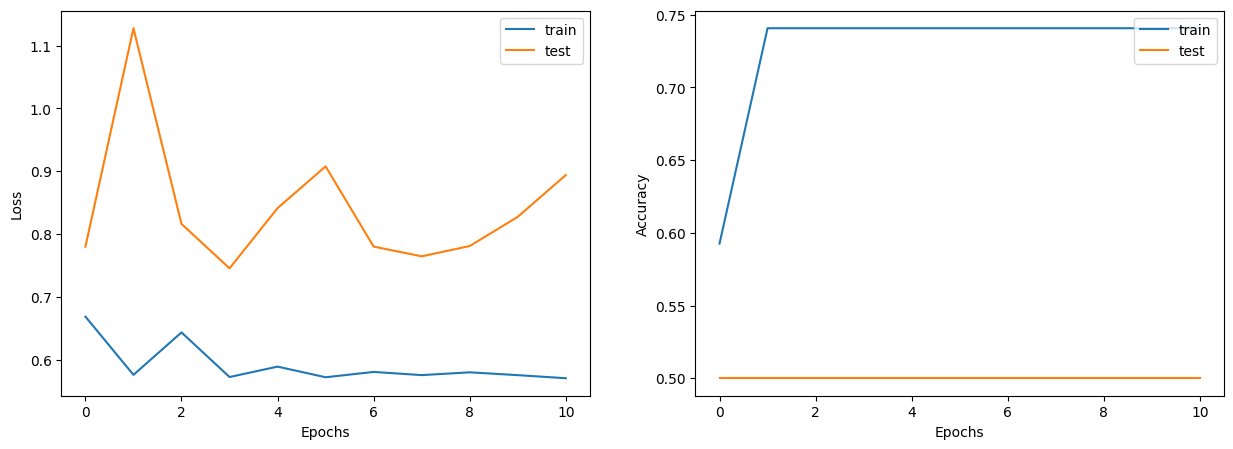

In [ ]:
display_learning_curves(history)

In [ ]:
x_test = test_data.Article_number.to_numpy()
print(x_test)
_, test_accuracy = gnn_model.evaluate(x=x_test, y=y_test, verbose=0)
print(f"Test accuracy: {round(test_accuracy * 100, 2)}%")

[4 2 3 1 4 1 2 4 1 1 2 3 2 3 3 2 1 1 2 4 4 1 3 2 1 3 2 3 3 3 2 3 3 2 3 1 2
 2 1 2 1 3 3 2 4 1 2 4 2 1 2]
Test accuracy: 72.55%


In [ ]:
logits = gnn_model.predict(tf.convert_to_tensor(x_test))
print(logits)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
[[0.30107218]
 [0.30230722]
 [0.3004346 ]
 [0.30491933]
 [0.30107218]
 [0.30491933]
 [0.30230722]
 [0.30107218]
 [0.30491933]
 [0.30491933]
 [0.30230722]
 [0.3004346 ]
 [0.30230722]
 [0.3004346 ]
 [0.3004346 ]
 [0.30230722]
 [0.30491933]
 [0.30491933]
 [0.30230722]
 [0.30107218]
 [0.30107218]
 [0.30491933]
 [0.3004346 ]
 [0.30230722]
 [0.30491933]
 [0.3004346 ]
 [0.30230722]
 [0.3004346 ]
 [0.3004346 ]
 [0.3004346 ]
 [0.30230722]
 [0.3004346 ]
 [0.3004346 ]
 [0.30230722]
 [0.3004346 ]
 [0.30491933]
 [0.30230722]
 [0.30230722]
 [0.30491933]
 [0.30230722]
 [0.30491933]
 [0.3004346 ]
 [0.3004346 ]
 [0.30230722]
 [0.30107218]
 [0.30491933]
 [0.30230722]
 [0.30107218]
 [0.3023072 ]
 [0.30491927]
 [0.3023072 ]]


In [ ]:
test_data

,Article_number,id,term_0,term_1,term_2,term_3,term_4,term_5,term_6,term_7,...,term_1826,term_1827,term_1828,term_1829,term_1830,term_1831,term_1832,term_1833,term_1834,Label
80,4,80,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0
49,2,49,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,1
64,3,64,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0
41,1,41,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0
77,4,77,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.154402,0.0,0.0,1
38,1,38,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0
57,2,57,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0
79,4,79,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.105987,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0
43,1,43,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0
36,1,36,0.000000,0.0,0.0,0.0,0.0,0.254365,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0


In [ ]:
len(test_data)

51

In [ ]:
threshold = 0.302
binary_labels=(logits>threshold).astype(int)
print(binary_labels)

[[0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]]


In [ ]:
len(binary_labels)

51

In [ ]:
for article_number, article_id, label in zip(test_data['Article_number'], test_data['id'], binary_labels):
    print(f"Article Number: {article_number}, ID: {article_id}, Binary Labels: {label}")

Article Number: 4, ID: 80, Binary Labels: [0]
Article Number: 2, ID: 49, Binary Labels: [1]
Article Number: 3, ID: 64, Binary Labels: [0]
Article Number: 1, ID: 41, Binary Labels: [1]
Article Number: 4, ID: 77, Binary Labels: [0]
Article Number: 1, ID: 38, Binary Labels: [1]
Article Number: 2, ID: 57, Binary Labels: [1]
Article Number: 4, ID: 79, Binary Labels: [0]
Article Number: 1, ID: 43, Binary Labels: [1]
Article Number: 1, ID: 36, Binary Labels: [1]
Article Number: 2, ID: 44, Binary Labels: [1]
Article Number: 3, ID: 74, Binary Labels: [0]
Article Number: 2, ID: 47, Binary Labels: [1]
Article Number: 3, ID: 68, Binary Labels: [0]
Article Number: 3, ID: 61, Binary Labels: [0]
Article Number: 2, ID: 55, Binary Labels: [1]
Article Number: 1, ID: 39, Binary Labels: [1]
Article Number: 1, ID: 40, Binary Labels: [1]
Article Number: 2, ID: 59, Binary Labels: [1]
Article Number: 4, ID: 78, Binary Labels: [0]
Article Number: 4, ID: 81, Binary Labels: [0]
Article Number: 1, ID: 31, Binary 

In [ ]:
result_df = pd.DataFrame({
    'Article_number': test_data['Article_number'],
    'Id': test_data['id'],
    'Binary_labels': binary_labels.flatten()
})

print(result_df)

    Article_number  Id  Binary_labels
80               4  80              0
49               2  49              1
64               3  64              0
41               1  41              1
77               4  77              0
38               1  38              1
57               2  57              1
79               4  79              0
43               1  43              1
36               1  36              1
44               2  44              1
74               3  74              0
47               2  47              1
68               3  68              0
61               3  61              0
55               2  55              1
39               1  39              1
40               1  40              1
59               2  59              1
78               4  78              0
81               4  81              0
31               1  31              1
69               3  69              0
46               2  46              1
37               1  37              1
73          

In [ ]:
class_sentences = {label: [] for label in range(len(binary_labels))}

for idx, label in enumerate(binary_labels):
    # Ensure label is scalar
    label = int(label)
    class_sentences[label].append(data['Sentence'].iloc[idx])

selected_sentences = class_sentences[1]

for sentence in selected_sentences:
    print(sentence)

This stereotype is stuck with the doll for years, despite the numerous new designs and models being introduced.
However, she shatters the glass as soon as she is done playing with the &amp;;doll&amp;; and gets down to business to tell a relatable, feminist, and applaud-worthy movie that lives up to the hype.Barbie, starring Margot Robbie in the lead, is set in Barbie Land which has several kinds of Barbies co-existing.
She begins to wonder about death, loses her ability to walk on her toes, and exhibits sad emotions.
When she approaches the &amp;;Weird Barbie&amp;; (Kate McKinnon), she learns that a portal between Barbie Land and the real world has led to Barbie feeling human-like emotions.
While Gloria is still a fan of Barbie, Sasha is not on board with the idea of Barbie and even calls her a fascist on her face.
Barbie soon understands that her questions are being answered but Ken goes off on a different journey of &amp;;self-discovery.&amp;; He learns that in the real world, men ar

/tmp/ipykernel_2486/551611854.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(label)


In [ ]:
len(selected_sentences)

30

In [ ]:
selected_sentences = []

for idx, (sentence, article_number) in enumerate(zip(data['Sentence'], test_data['Article_number'])):
    label = binary_labels[idx]
    if label == 1:
        selected_sentences.append((sentence, article_number))

for sentence, article_number in selected_sentences:
    print(f"Article Number: {article_number}, Sentence: {sentence}")

Article Number: 2, Sentence: This stereotype is stuck with the doll for years, despite the numerous new designs and models being introduced.
Article Number: 1, Sentence: However, she shatters the glass as soon as she is done playing with the &amp;;doll&amp;; and gets down to business to tell a relatable, feminist, and applaud-worthy movie that lives up to the hype.Barbie, starring Margot Robbie in the lead, is set in Barbie Land which has several kinds of Barbies co-existing.
Article Number: 1, Sentence: She begins to wonder about death, loses her ability to walk on her toes, and exhibits sad emotions.
Article Number: 2, Sentence: When she approaches the &amp;;Weird Barbie&amp;; (Kate McKinnon), she learns that a portal between Barbie Land and the real world has led to Barbie feeling human-like emotions.
Article Number: 1, Sentence: While Gloria is still a fan of Barbie, Sasha is not on board with the idea of Barbie and even calls her a fascist on her face.
Article Number: 1, Sentence:

In [ ]:
article_sentences = {}

for sentence, article_number in selected_sentences:
    if article_number not in article_sentences:
        article_sentences[article_number] = []
    article_sentences[article_number].append(sentence)

for article_number, sentences in article_sentences.items():
    article_paragraph = ', '.join(sentences)
    print(f"Article Number: {article_number}\nParagraph:\n{article_paragraph}\n")


Article Number: 2
Paragraph:
This stereotype is stuck with the doll for years, despite the numerous new designs and models being introduced., When she approaches the &amp;;Weird Barbie&amp;; (Kate McKinnon), she learns that a portal between Barbie Land and the real world has led to Barbie feeling human-like emotions., On the other hand, Barbie also lands in her own world with the mother-daughter duo and finds out everything is changing., How will Barbie save her world?, She is conveying some of the most powerful messages with the film, she is doing it under the garb of humour and coming-of-age, making the impact stronger.The dialogues and screenplay are the biggest superpowers of Barbie., Barbie is so strong in its approach towards surprise humour that it somewhat reminded me of Phoebe Waller-Bridge&amp;;s style of comedy.On the acting front, Margot proves she was meant to play the role of Barbie., His rapport with Simu Liu in the film, especially in their musical scenes, is hilarious 

In [ ]:
article_paragraph

"However, she shatters the glass as soon as she is done playing with the &amp;;doll&amp;; and gets down to business to tell a relatable, feminist, and applaud-worthy movie that lives up to the hype.Barbie, starring Margot Robbie in the lead, is set in Barbie Land which has several kinds of Barbies co-existing., She begins to wonder about death, loses her ability to walk on her toes, and exhibits sad emotions., While Gloria is still a fan of Barbie, Sasha is not on board with the idea of Barbie and even calls her a fascist on her face., Barbie soon understands that her questions are being answered but Ken goes off on a different journey of &amp;;self-discovery.&amp;; He learns that in the real world, men are treated higher than women and that the concept of patriarchy plays to their benefit.Ken returns to Barbie Land and brings about drastic changes., Greta makes several pop culture references thus adopting the meta narration which helps Barbie take things a notch higher., She also take

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Classroom/English/english_train.csv')

for idx in [1, 2]:

    print("=" * 80)
    print(f"ARTICLE NUMBER {idx}")
    print("=" * 80)

    print("\nORIGINAL ARTICLE:\n")
    print(df.iloc[idx]['Article'])

    print("\nACTUAL HUMAN SUMMARY:\n")
    print(df.iloc[idx]['Summary'])

    print("\n\n")

ARTICLE NUMBER 1

ORIGINAL ARTICLE:

The highly anticipated Gadar 2, starring Sunny Deol and Ameesha Patel, is generating excitement among fans. According to a report from Bollywood Hungama, the trailer of Gadar 2 was earlier expected to release on July 27. However, sources close to the production have now claimed otherwise.A source close to the film told News18 exclusively that Gadar 2 makers have preponed their plans for the trailer release. The trailer will now release earlier. &amp;#8220;Director Anil Sharma and actor Sunny Deol are now planning to launch it on July 25,&amp;#8221; said the source.According to the source, the makers of Gadar 2 have devised an interesting promotional strategy. They are relying on the efforts of the actors and director Anil Sharma to generate enough buzz and awareness about the film&amp;#8217;s release on August 11. As of now, there has been no official statement from the makers regarding the trailer release.Gadar 2, announced in October 2021, is a re

In [ ]:
article_1 = df.iloc[1]
summary_article_1 = article_1['Summary']

article_2 = df.iloc[2]
summary_article_2 = article_2['Summary']

In [ ]:
pip install rouge-score


  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=a903d43f3023068aaeb95355db4372d3e7f0bcda30d227822433b5b46b98b983
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [ ]:
pip install evaluate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.6 MB/s eta 0:00:00


In [ ]:
pip install rouge


In [ ]:
!pip install rouge


In [ ]:
from rouge import Rouge

rouge = Rouge()

generated_summary_1 = " ".join(article_sentences[1])

scores_1 = rouge.get_scores(
    generated_summary_1,
    summary_article_1,
    avg=True
)

print("ARTICLE 1")
print("ROUGE-1 F1:", scores_1['rouge-1']['f'])
print("ROUGE-2 F1:", scores_1['rouge-2']['f'])
print("ROUGE-L F1:", scores_1['rouge-l']['f'])

ARTICLE 1
ROUGE-1 F1: 0.08429118632433466
ROUGE-2 F1: 0.02144772016473925
ROUGE-L F1: 0.06130268057720824


In [ ]:
generated_summary_2 = " ".join(article_sentences[2])

scores_2 = rouge.get_scores(
    generated_summary_2,
    summary_article_2,
    avg=True
)

print("ARTICLE 2")
print("ROUGE-1 F1:", scores_2['rouge-1']['f'])
print("ROUGE-2 F1:", scores_2['rouge-2']['f'])
print("ROUGE-L F1:", scores_2['rouge-l']['f'])

ARTICLE 2
ROUGE-1 F1: 0.12403100619193559
ROUGE-2 F1: 0.021563341250063626
ROUGE-L F1: 0.09302325425395111


In [ ]:
from rouge import Rouge

rouge = Rouge()

generated_summaries = [
    " ".join(article_sentences[1]),
    " ".join(article_sentences[2])
]

actual_summaries = [
    summary_article_1,
    summary_article_2
]

scores = rouge.get_scores(
    generated_summaries,
    actual_summaries,
    avg=True
)

print("AVERAGE ROUGE SCORES")
print()

print("ROUGE-1 Precision:", scores['rouge-1']['p'])
print("ROUGE-1 Recall:", scores['rouge-1']['r'])
print("ROUGE-1 F1:", scores['rouge-1']['f'])

print()

print("ROUGE-2 Precision:", scores['rouge-2']['p'])
print("ROUGE-2 Recall:", scores['rouge-2']['r'])
print("ROUGE-2 F1:", scores['rouge-2']['f'])

print()

print("ROUGE-L Precision:", scores['rouge-l']['p'])
print("ROUGE-L Recall:", scores['rouge-l']['r'])
print("ROUGE-L F1:", scores['rouge-l']['f'])

AVERAGE ROUGE SCORES

ROUGE-1 Precision: 0.056719881848231235
ROUGE-1 Recall: 0.6386363636363637
ROUGE-1 F1: 0.10416109625813513

ROUGE-2 Precision: 0.011380008093889114
ROUGE-2 Recall: 0.19523809523809524
ROUGE-2 F1: 0.021505530707401438

ROUGE-L Precision: 0.042021239187003304
ROUGE-L Recall: 0.4727272727272727
ROUGE-L F1: 0.07716296741557968
